1. RF classifier (SMOTE + GridSearchCV hyperparameter tuning)
2. Y2H degree centrality percentile 

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, pearsonr
from tqdm import trange
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import shap

#DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"
#DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
MS_COLOR_LIGHT = "#EECC66" #color for static (in complex)
MS_COLOR_DARK  = "#997700" #color for dynamic (not in complex)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [2]:
# load the datasets with node centrality information and get nodes in both
#ms_nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")
#y2h_nodes = pd.read_csv(f"{DATA_PATH3}Y2H-s288c-step18.csv")
nodes = pd.read_pickle(f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl")

# --- Flip sign of cagiada-dG ---
nodes["cagiada-dG"] = -nodes["cagiada-dG"]

# CHAPERONE CATEGORY: three-way classification ===
def fix_list(val):
    if isinstance(val, list):
        return val
    elif isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    elif pd.isnull(val):
        return []
    else:
        return []

nodes['interacting_chaperones'] = nodes['interacting_chaperones'].apply(fix_list)

def chaperone_category(row):
    node = row['node']
    chaps = row['interacting_chaperones']
    if not chaps or chaps == []:
        return 'protein_is_neither_chaperone_nor_interacts'
    elif node in chaps:
        return 'protein_is_chaperone'
    else:
        return 'protein_interacts_with_chaperone'

nodes['chaperone_category'] = nodes.apply(chaperone_category, axis=1)

# ONE-HOT ENCODE CHAPERONE CATEGORY
nodes['is_chaperone'] = (nodes['chaperone_category'] == 'protein_is_chaperone').astype(int)
nodes['interacts_with_chaperone'] = (nodes['chaperone_category'] == 'protein_interacts_with_chaperone').astype(int)
nodes['neither_chaperone_nor_interacts'] = (nodes['chaperone_category'] == 'protein_is_neither_chaperone_nor_interacts').astype(int)

#y2h_nodes = y2h_nodes.merge(abundance_df, on="node", how="left")

#shared_nodes = set(ms_nodes["node"]) & set(y2h_nodes["node"])
#print (f"A total of {len(shared_nodes)} nodes are shared between the MS and Y2H networks")
#list(nodes.columns)

In [3]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2466


In [4]:
# determine which nodes are hubs based on percentile cutoff for betweenness centrality
cut = 0.10
#ms_threshold = filtered_nodes['betweenness_centrality'].quantile(1 - cut)
#ms_hubs     = filtered_nodes[filtered_nodes['betweenness_centrality'] >= ms_threshold]
#ms_nothub   = filtered_nodes[filtered_nodes['betweenness_centrality'] <  ms_threshold]

y2h_threshold = filtered_nodes['Y2H_degree_centrality'].quantile(1 - cut)
y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] >= y2h_threshold]
y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] <  y2h_threshold]

#print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in Y2H data is 0.00297; there are 116 hubs and 866 non hubs


In [5]:
# SCRIPT 2: Feature & Target Preparation
# Create target column if not already created
filtered_nodes['y2h_hubs'] = (filtered_nodes['Y2H_degree_centrality'] >= y2h_threshold).astype(int)

# 2. Feature & Target Preparation
ml_features = [
    'Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score',
    'Villen_halflife_min',
    'mean_molecules_per_cell',
    'interacts_with_chaperone', 'in_complex',
    'essential',
    'meltome-melting-point', 'N_aa_disordered', 'disorder_fraction', 'mean_plddt'
]

X = filtered_nodes[ml_features].copy()
y = filtered_nodes['y2h_hubs'].copy()

# Replace common string indicators of missing values with NaN, then convert to numeric
missing_indicators = [
    'n.d.', 'N.D.', 'nd', 'ND', 'na', 'NA', 'null', 'NULL',
    'missing', 'MISSING', '-', 'n/a', 'N/A', ''
]

for col in ml_features:
    X[col] = X[col].replace(missing_indicators, np.nan)
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill remaining NaNs with -999 (important for sklearn RF)
X_filled = X.fillna(-999)

print("✅ Data preparation complete")
print(f"Total usable samples: {len(X_filled)}")

✅ Data preparation complete
Total usable samples: 2466


In [6]:
# Version 4: SMOTE + GridSearchCV hyperparameter tuning
X_train, X_test, y_train, y_test = train_test_split(
    X_filled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print(f"✅ Data split completed:")
# ✅ Use SMOTE inside a pipeline to avoid data leakage
rf = RandomForestClassifier(random_state=42)
smote_rf_pipe = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", rf)
])
param_grid = {
    'rf__n_estimators': [200, 300, 400],
    'rf__max_depth': [10, 20, 30],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2],
    'rf__max_features': ['sqrt', 'log2'],
    'rf__class_weight': ['balanced']
}
gs = GridSearchCV(
    smote_rf_pipe,
    param_grid=param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), # ✅ reproducible CV
    n_jobs=-1,
    verbose=1
)
gs.fit(X_train, y_train)
print(f"✅ Best params: {gs.best_params_}")
rf_model = gs.best_estimator_
print(f"✅ Random Forest model trained")
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]
bal_accuracy = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
print(f"\n📊 Model Performance:")
print(f"Balanced Accuracy: {bal_accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Confusion Matrix:")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"True Positive Rate (Recall): {tp / (tp + fn):.3f}")
print(f"False Positive Rate: {fp / (fp + tn):.3f}")
print(f"\n🔍 Computing SHAP values...")
np.random.seed(42)
explainer = shap.TreeExplainer(rf_model.named_steps['rf']) # ✅ SHAP only on trained RF
X_test_scaled = X_test
shap_values = explainer.shap_values(X_test_scaled)
if isinstance(shap_values, list):
    shap_class_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_class_values = shap_values[:, :, 1]
else:
    shap_class_values = shap_values

✅ Data split completed:
Fitting 5 folds for each of 72 candidates, totalling 360 fits
✅ Best params: {'rf__class_weight': 'balanced', 'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
✅ Random Forest model trained

📊 Model Performance:
Balanced Accuracy: 0.595
Precision: 0.098
Recall: 0.348
F1-Score: 0.152
ROC-AUC: 0.698

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.84      0.90       471
           1       0.10      0.35      0.15        23

    accuracy                           0.82       494
   macro avg       0.53      0.60      0.53       494
weighted avg       0.92      0.82      0.86       494


📊 Confusion Matrix:
TP: 8, FP: 74, TN: 397, FN: 15
True Positive Rate (Recall): 0.348
False Positive Rate: 0.157

🔍 Computing SHAP values...


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_8329/3808070121.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


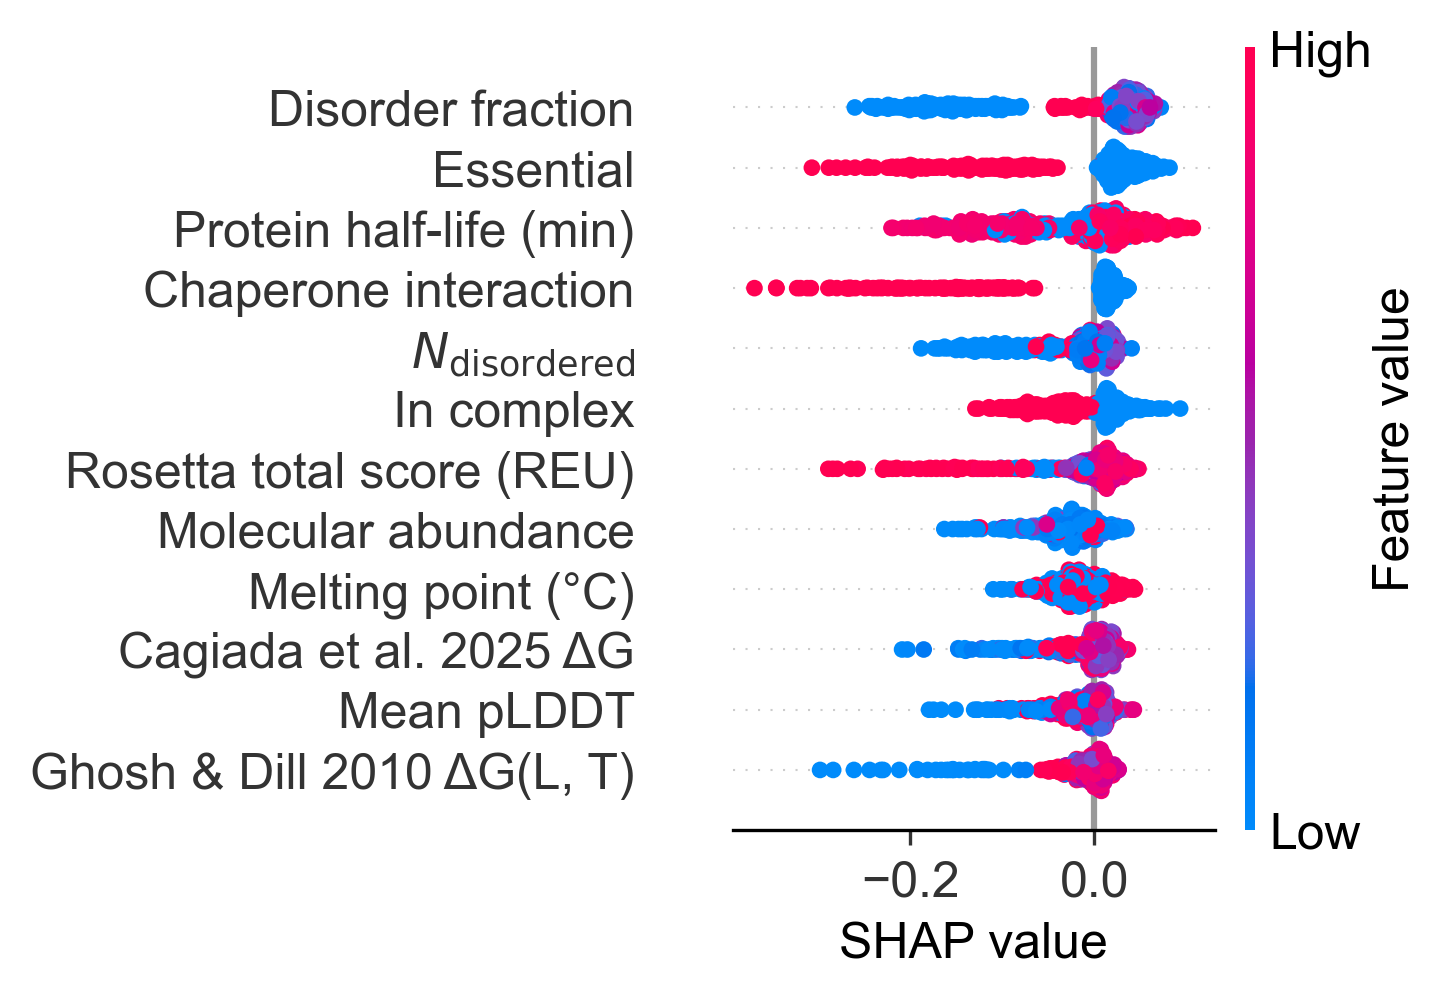

In [7]:
# Map original feature names to publication labels
rename_map = {
    'Ghosh-Dill-dG': 'Ghosh & Dill 2010 ΔG(L, T)', 
    'cagiada-dG': 'Cagiada et al. 2025 ΔG', 
    'Rosetta_best_total_score': 'Rosetta total score (REU)',
    'Villen_halflife_min': 'Protein half-life (min)',
    'mean_molecules_per_cell': 'Molecular abundance',
    'interacts_with_chaperone': 'Chaperone interaction', 
    'in_complex': 'In complex',
    'essential': 'Essential',
    'meltome-melting-point': 'Melting point (°C)',  
    'N_aa_disordered': r"$N_{\mathrm{disordered}}$",
    'disorder_fraction': 'Disorder fraction', 
    'mean_plddt': 'Mean pLDDT'
}

# Prepare display names for SHAP plot - use actual feature names from X_train
feature_names_list = list(X_train.columns)
display_names = [rename_map.get(f, f) for f in feature_names_list]

# SHAP Summary Plot (top 10 features)
fig, ax = plt.subplots(figsize=(2, 2))
shap.summary_plot(
    shap_class_values,
    X_test,
    feature_names=display_names,
    plot_type='dot',
    max_display=12,
    show=False
)
# Get the figure SHAP created
fig = plt.gcf()
ax = plt.gca()
# --- FORCE SHAP FONT STYLES (Arial, bold, size 11) ---
for text in fig.findobj(match=plt.Text):
    text.set_fontfamily("Arial")
    text.set_fontsize(12)
    text.set_fontweight("normal")
# Fix axis labels & ticks
ax.set_xlabel("SHAP value", fontsize=12, fontweight="normal", fontfamily="Arial")
ax.set_ylabel("", fontsize=12, fontweight="normal", fontfamily="Arial")

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Arial")
    label.set_fontsize(12)
    label.set_fontweight("normal")
plt.tight_layout()

# Save as high-resolution PDF
fig.set_size_inches(3, 3)
fig.savefig('SHAPRandom_forest12.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()



🌲 Random Forest Gini-based Feature Importances:
                   Feature  Gini Importance
       Molecular abundance         0.117897
         Disorder fraction         0.117825
   Protein half-life (min)         0.111744
 $N_{\mathrm{disordered}}$         0.103564
 Rosetta total score (REU)         0.094747
    Cagiada et al. 2025 ΔG         0.078449
        Melting point (°C)         0.076951
Ghosh & Dill 2010 ΔG(L, T)         0.075618
                Mean pLDDT         0.075215
                 Essential         0.061669
     Chaperone interaction         0.050537
                In complex         0.035783

📈 Generating comprehensive ROC data for Origin plotting...
Minimal ROC data saved to 'roc_model12.csv'
✅ ROC Data Generated:
 Total data points: 45
 AUC Score: 0.697591
 FPR range: 0.000000 to 1.000000
 TPR range: 0.000000 to 1.000000
 Threshold range: 0.001061 to inf

📋 Complete ROC Data (Copy-Paste Ready for Origin):
# ROC Curve Data
# False_Positive_Rate	True_Positive_Rate

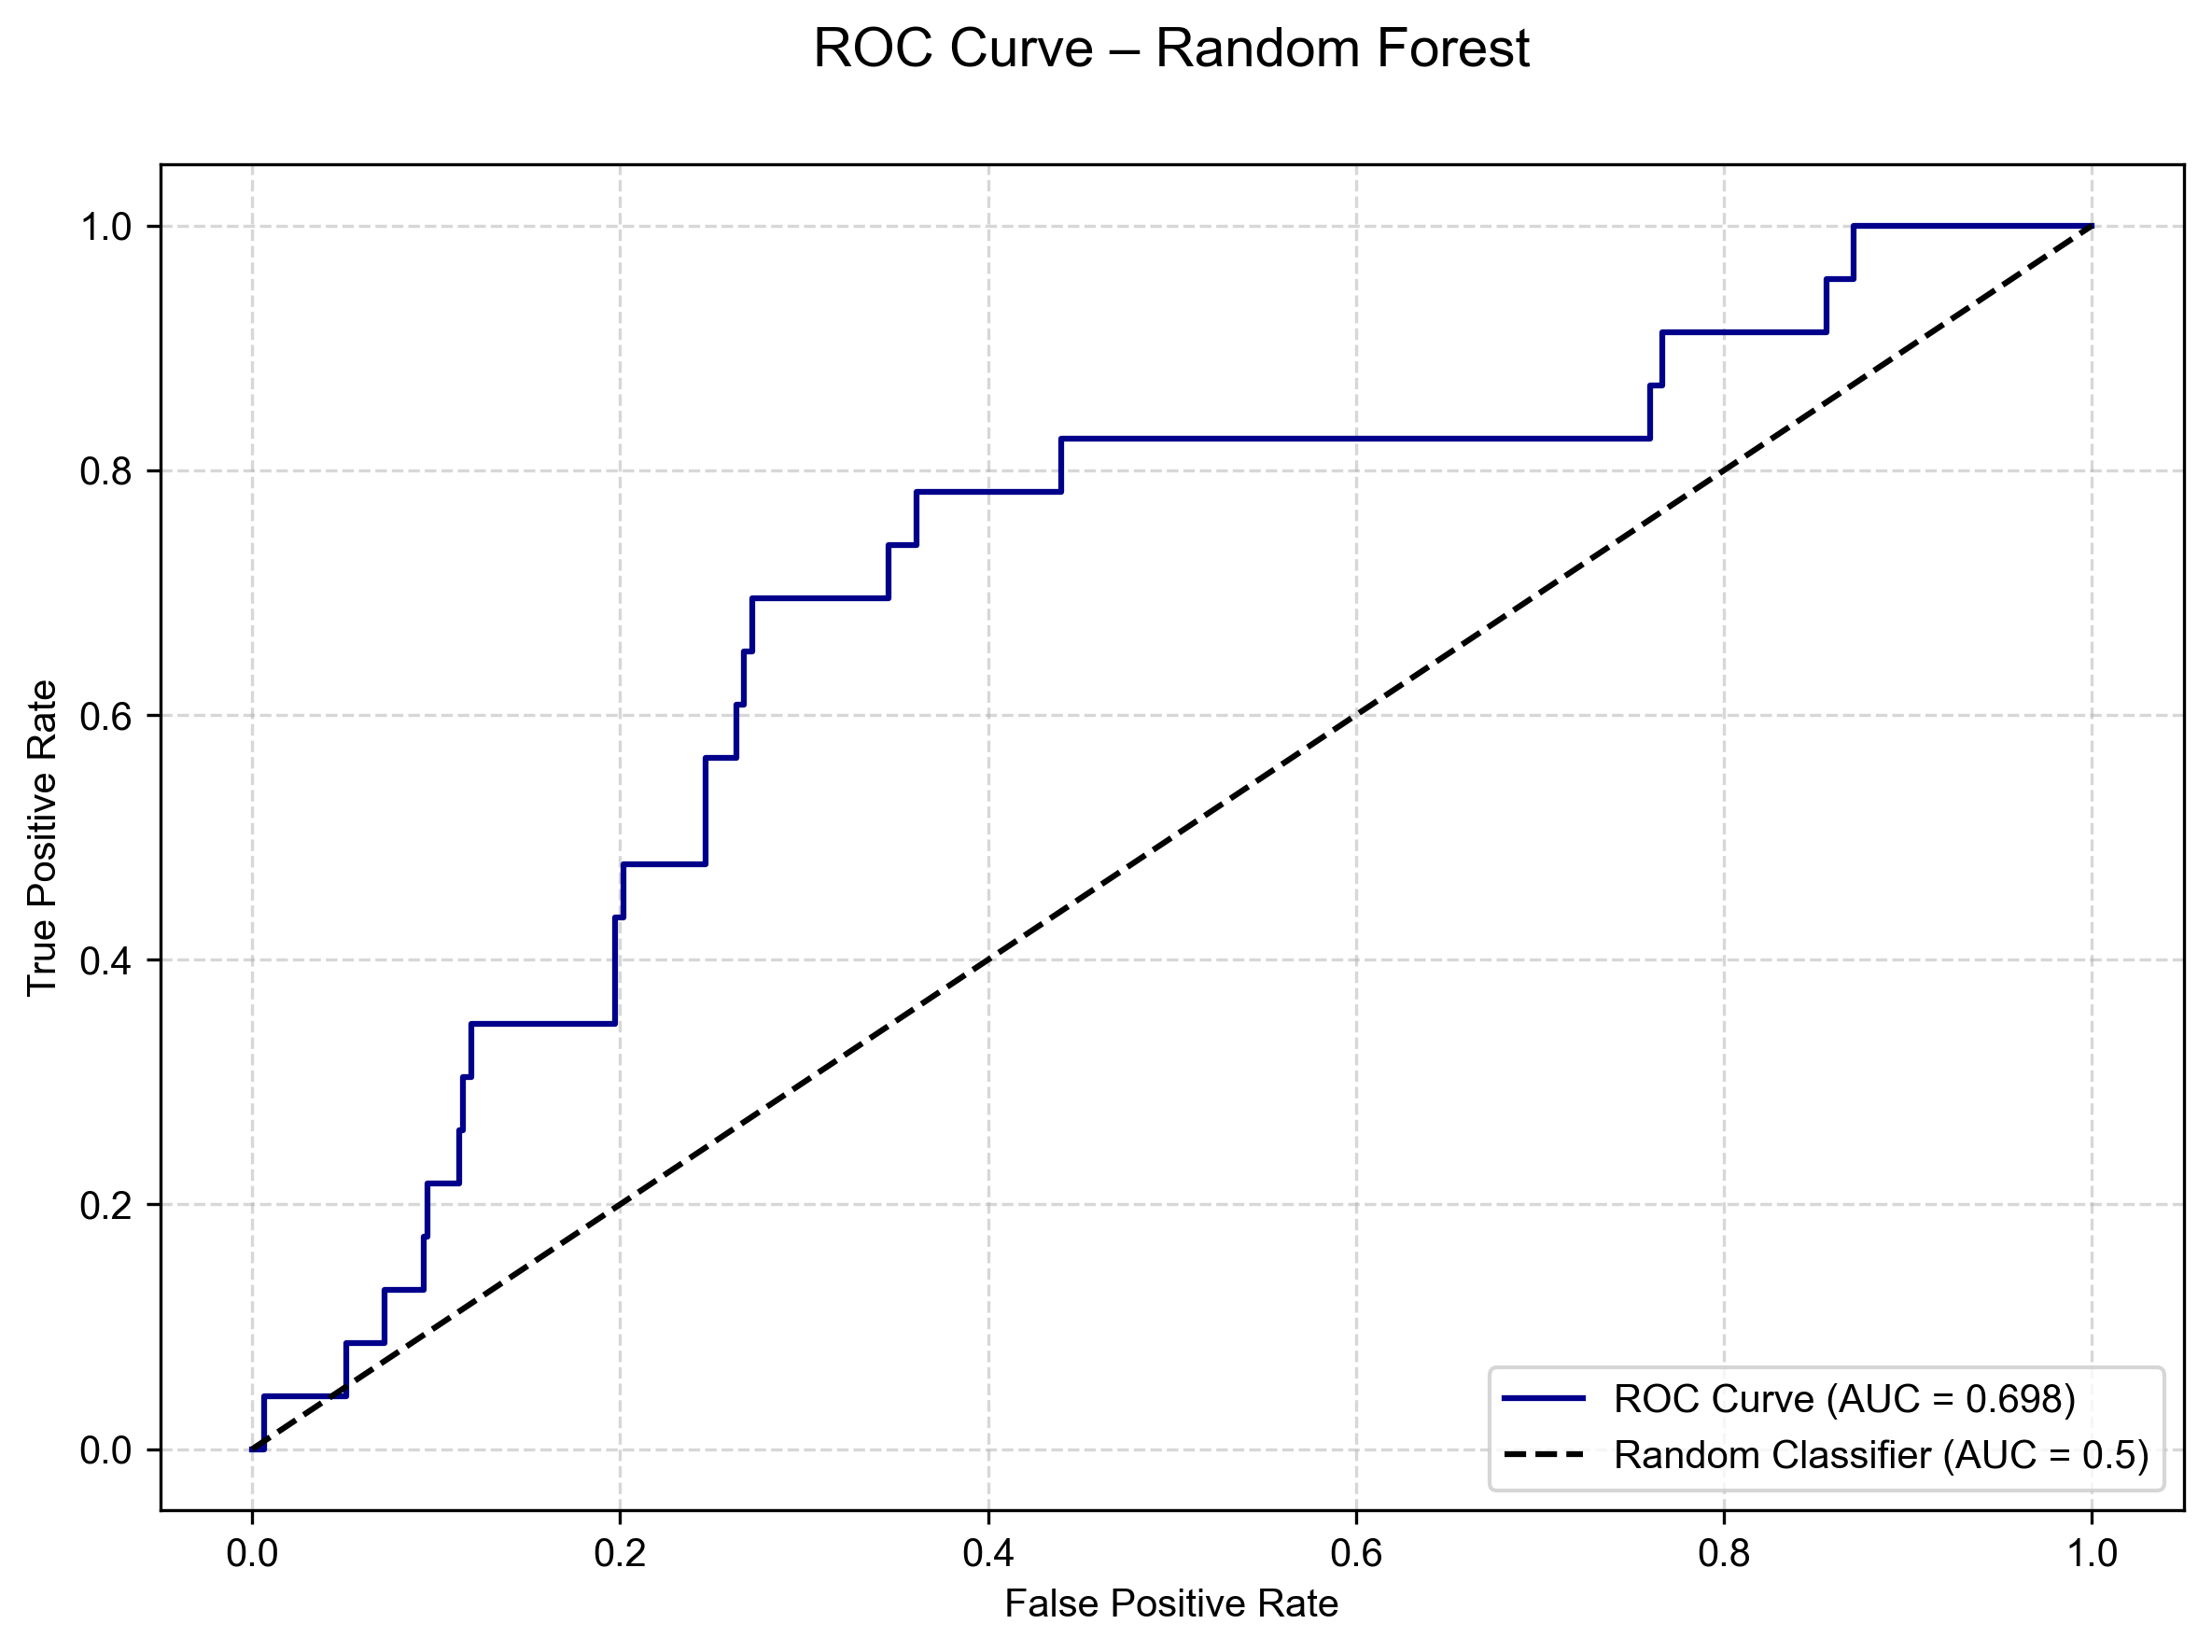

In [8]:
# -----------------------------
# 🌲 Gini-based Feature Importance
# -----------------------------
print("\n🌲 Random Forest Gini-based Feature Importances:")
# Access the trained Random Forest inside the pipeline
trained_rf = rf_model.named_steps['rf']
importances = trained_rf.feature_importances_
# Use display_names for feature names (already mapped earlier)
feature_names = display_names
# Create and display sorted DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Gini Importance': importances
}).sort_values(by='Gini Importance', ascending=False)
print(importance_df.to_string(index=False))
# -----------------------------------
# 🔍 Enhanced ROC Data Export for Origin Plotting
# -----------------------------------
print(f"\n📈 Generating comprehensive ROC data for Origin plotting...")
# Generate ROC curve data
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Save minimal ROC data (FPR and TPR only) to CSV
roc_minimal_df = pd.DataFrame({
    'False_Positive_Rate': fpr,
    'True_Positive_Rate': tpr
})
roc_minimal_df.to_csv('roc_model12.csv', index=False)  # Change filename for each model, e.g., roc_model2.csv
print("Minimal ROC data saved to 'roc_model12.csv'")

# Create comprehensive ROC DataFrame for export
roc_df = pd.DataFrame({
    'False_Positive_Rate': fpr,
    'True_Positive_Rate': tpr,
    'Threshold': thresholds,
    'Specificity': 1 - fpr, # 1 - FPR
    'Sensitivity': tpr, # Same as TPR
    'Point_Index': range(len(fpr))
})
# Add additional calculated metrics
roc_df['Youden_J'] = roc_df['True_Positive_Rate'] + roc_df['Specificity'] - 1
roc_df['Distance_to_Perfect'] = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)
# Display ROC data summary
print(f"✅ ROC Data Generated:")
print(f" Total data points: {len(roc_df)}")
print(f" AUC Score: {roc_auc:.6f}")
print(f" FPR range: {fpr.min():.6f} to {fpr.max():.6f}")
print(f" TPR range: {tpr.min():.6f} to {tpr.max():.6f}")
print(f" Threshold range: {thresholds.min():.6f} to {thresholds.max():.6f}")
# Optional: Print all data in copy-pasteable format
print(f"\n📋 Complete ROC Data (Copy-Paste Ready for Origin):")
print("# ROC Curve Data")
print("# False_Positive_Rate\tTrue_Positive_Rate\tThreshold\tSpecificity\tSensitivity\tPoint_Index\tYouden_J\tDistance_to_Perfect")
for idx, row in roc_df.iterrows():
    print(f"{row['False_Positive_Rate']:.8f}\t{row['True_Positive_Rate']:.8f}\t{row['Threshold']:.8f}\t{row['Specificity']:.8f}\t{row['Sensitivity']:.8f}\t{row['Point_Index']}\t{row['Youden_J']:.8f}\t{row['Distance_to_Perfect']:.8f}")
# -----------------------------------
# 🧪 Visual ROC Curve for Smoothness Check
# -----------------------------------
plt.figure(figsize=(8, 6))
plt.plot(roc_df['False_Positive_Rate'], roc_df['True_Positive_Rate'], label=f'ROC Curve (AUC = {roc_auc:.3f})', color='darkblue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()